# Imports

In [1]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys 
import scanpy as sc
import warnings
import scanpy as sc
import anndata as ad
import os
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)

main_dir = '../'
# task_grn_inference_dir = '../../'
output_dir = f"{main_dir}/output/"

# - local imports 
from ciim.src.tf_activity.helper import adata_lambda
from ciim.src.common import v_datasets, datasets, datasets_all, datasets_disease, cell_types, surrogate_names, colors_blind, palette_cell_types, palette_datasets, palette_datasets_pretty, palette_gender, palette_sub_types
from ciim.src.utils.util import plot_umap

to_save = f'/vol/projects/jnourisa/datasets/umap/'
os.makedirs(to_save, exist_ok=True)

# ATAC

In [ ]:
adata = ad.read_h5ad('/vol/projects/CIIM/Healthy_Single_Cell_Data/count_matrix/data6_CMtx.h5ad')

In [ ]:
adata

# COVID

In [14]:
df = pd.read_csv("/vol/projects/CIIM/Covid_50MHH/sample_table_new_RNA.txt", sep='\t')
print(df.groupby(['New_Severity', 'Sex']).size())

New_Severity  Sex
mild          F       5
              M      12
post          F      10
              M      17
severe        F       7
              M      13
dtype: int64


# UMAP

## Single cell of all data

In [19]:
if False:
    lambda_sc_adata = lambda dataaset:  f'/vol/projects/jnourisa/datasets/{dataset}_raw.h5ad'
    for dataset in datasets:
        adata = ad.read_h5ad(lambda_sc_adata(dataset))
        adata.obs['Major_CT'].dropna(inplace=True)
        adata = adata[adata.obs['Major_CT'].isin(cell_types)]
        adata.obs['Major_CT'] = pd.Categorical(adata.obs['Major_CT'], categories=cell_types, ordered=True)

        sc.pp.normalize_total(adata)
        sc.pp.log1p(adata)
        sc.pp.highly_variable_genes(adata, n_top_genes=2000)

        sc.pp.pca(adata, use_highly_variable=True)  
        sc.pp.neighbors(adata, n_neighbors=15)  
        sc.tl.umap(adata)  
        adata.write(f'{to_save}/{dataset}_umap.h5ad')
else:
    adata_dict = {}
    for dataset in datasets:
        adata = ad.read_h5ad(f'{to_save}/{dataset}_umap.h5ad')
        adata_dict[dataset] = adata

KeyboardInterrupt: 

In [7]:
adata1 = adata_dict[datasets[0]]
adata2 = adata_dict[datasets[1]]

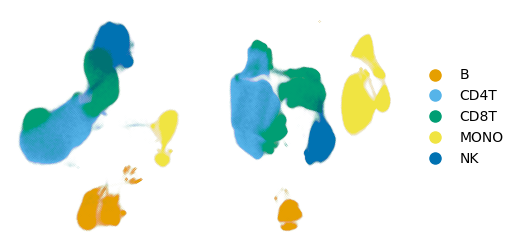

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(5, 3))
ax = axes[0]
plot_umap(adata1, color='Major_CT', ax=ax, s=.002, X_label='X_umap', alpha=0.1, palette=palette_cell_types)  
ax.get_legend().remove()
ax = axes[1]
plot_umap(adata2, color='Major_CT', ax=ax, s=.002, X_label='X_umap', alpha=0.1, palette=palette_cell_types) 
plt.savefig(f'{output_dir}/umap.png', bbox_inches='tight', dpi=300)

## Single cell of sub types

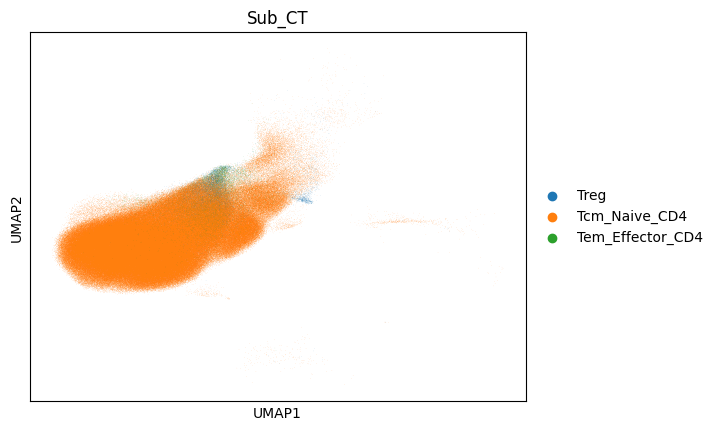

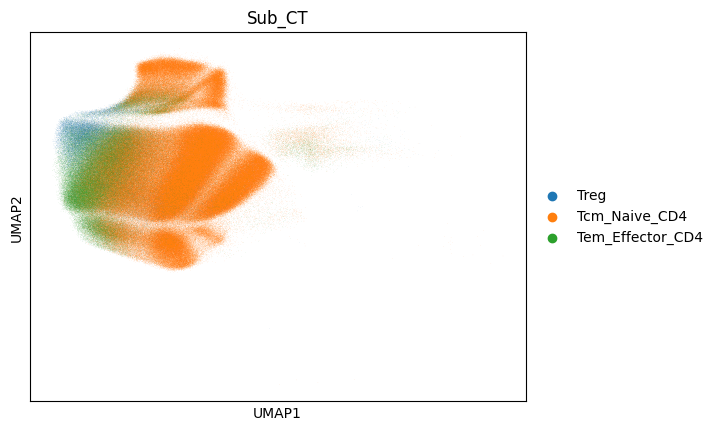

In [22]:
cell_type = 'CD4T'
adata1_sub = adata1[adata1.obs['Major_CT']==cell_type]
# fig, ax = plt.subplots(1, 1, figsize=(5, 5))
# plot_umap(adata1_sub, color='Sub_CT', ax=ax, s=.1, X_label='X_pca', alpha=0.1, palette=palette_sub_types)  
sc.pl.umap(adata1_sub, color='Sub_CT')

adata2_sub = adata2[adata2.obs['Major_CT']==cell_type]
# fig, ax = plt.subplots(1, 1, figsize=(5, 5))
# plot_umap(adata2_sub, color='Sub_CT', ax=ax, s=.1, X_label='X_pca', alpha=0.1, palette=palette_sub_types)  
sc.pl.umap(adata2_sub, color='Sub_CT')

## Bulk data

IndexError: index 4 is out of bounds for axis 0 with size 4

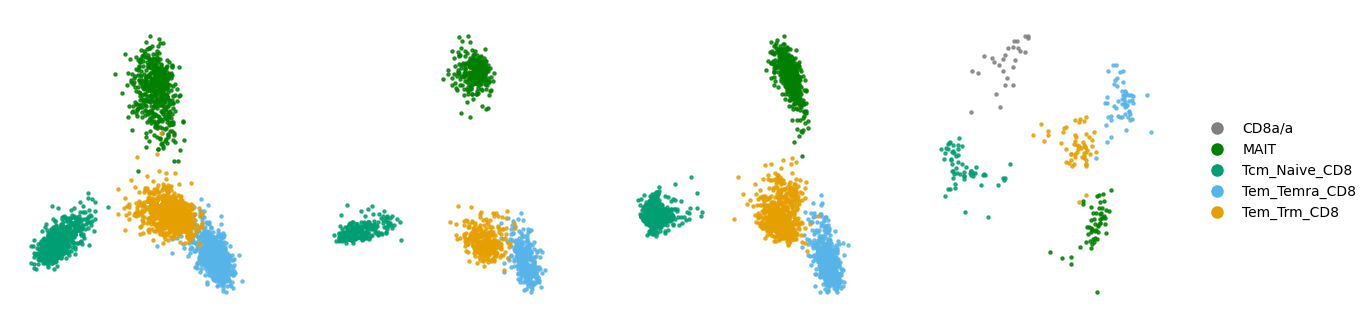

In [ ]:
os.makedirs('../output/temp/umap/', exist_ok=True)
run_umap = False

for j, cell_type in enumerate(['CD8T', 'CD4T', 'MONO']):
    fig, axes = plt.subplots(1, 4, figsize=(15, 4))
    for i, dataset in enumerate(datasets+v_datasets):
        ax = axes[i]
        if run_umap:
            adata = ad.read_h5ad(f'/vol/projects/jnourisa/datasets/{dataset}_bulk_minor.h5ad', backed='r')
            adata = adata[adata.obs['Major_CT'] == cell_type].to_memory()
            sc.pp.highly_variable_genes(adata, n_top_genes=2000)
            sc.pp.pca(adata, use_highly_variable=True)  
            sc.pp.neighbors(adata, n_neighbors=15)  
            sc.tl.umap(adata) 
            adata.write(f'../output/temp/umap/{cell_type}_{dataset}_bulk_minor.h5ad')
        else:
            adata = ad.read_h5ad(f'../output/temp/umap/{cell_type}_{dataset}_bulk_minor.h5ad')
        plot_umap(adata, color='Sub_CT', ax=ax, s=5, X_label='X_pca', alpha=0.8, palette=palette_sub_types) 
        # sc.pl.umap(adata, color='Sub_CT', ax=ax, palette=palette_sub_types)
        
        if i != len(axes)-1:
            ax.get_legend().remove()
    # plt.tight_layout()

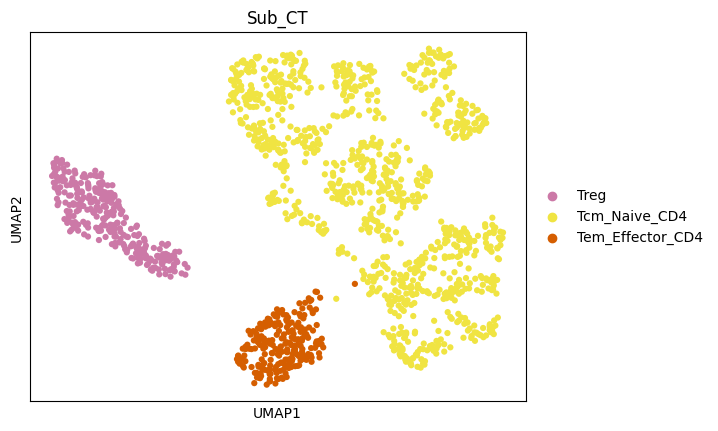

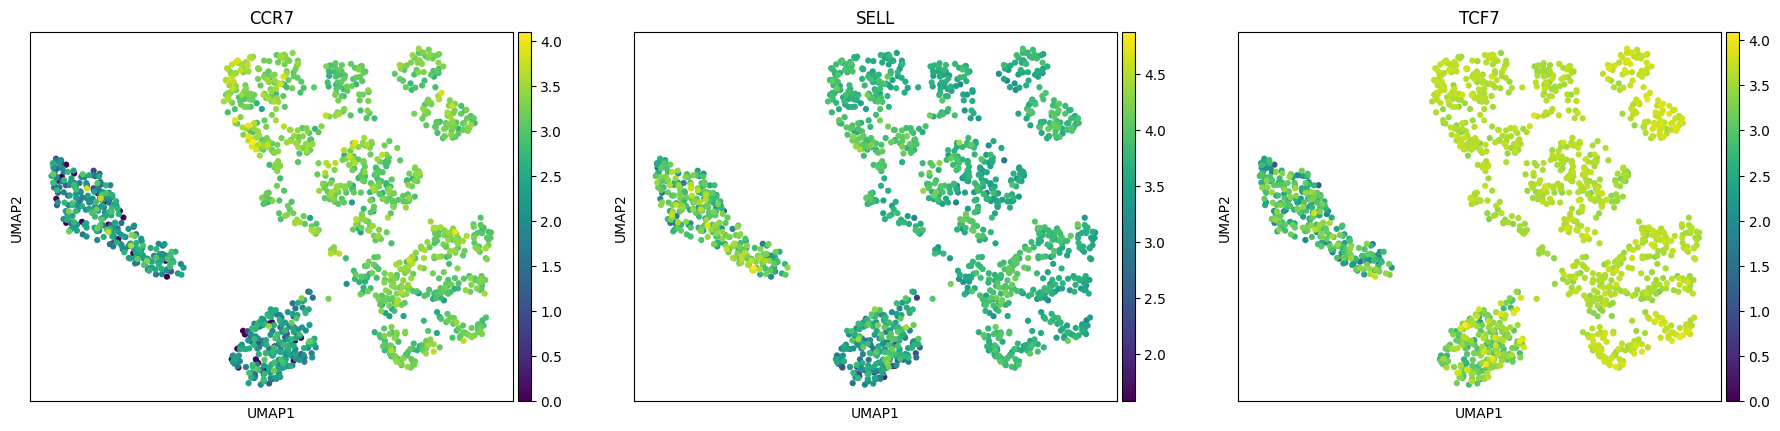

In [55]:

for j, cell_type in enumerate(['CD4T']):
    for i, dataset in enumerate(datasets[0:1]):
        adata = ad.read_h5ad(f'../output/temp/umap/{cell_type}_{dataset}_bulk_minor.h5ad')
        # plot_umap(adata, color='Sub_CT', ax=ax, s=1, X_label='X_pca', alpha=0.8, palette=palette_sub_types) 
        sc.pl.umap(adata, color=['Sub_CT', ], palette=palette_sub_types)
        sc.pl.umap(adata, color=['CCR7', 'SELL', 'TCF7'], cmap='viridis') # tcm native
        # sc.pl.umap(adata, color=['FOXP3', 'IL2RA', 'CTLA4'], cmap='viridis') # treg 
        # sc.pl.umap(adata, color=['IFNG', 'RORC', 'TBX21'], cmap='viridis') # effector
        # sc.pl.umap(adata, color=['CD8B', 'S100B', 'CCR7', 'RGS10', 'NOSIP', 'LINC02446', 'LEF1', 'CRTAM', 'CD8A'], cmap='viridis') # naive
        # sc.pl.umap(adata, color=['CD8B', 'ANXA1', 'CD8A', 'KRT1', 'LINC02446', 'YBX3', 'IL7R', 'TRAC', 'NELL2', 'LDHB'], cmap='viridis') # tcm

# Cell count: pseudobulking

In [10]:
# from task_grn_inference.src.exp_analysis.helper import plot_cumulative_density
# fig, ax = plt.subplots(1, 1, figsize=(3, 3), sharey=True)
# for i, dataset in enumerate(par['datasets']):
#     adata = adata_lambda(dataset)
#     cell_count = adata.obs['cell_count']
#     plot_cumulative_density(cell_count, ax=ax, label=dataset)
#     ax.set_xlabel('Cell count')
#     ax.set_ylabel('Cumulative density')
#     ax.set_xscale('log')
# plt.legend(loc=(1, .5))

# Stats

In [15]:
data_store = []
for dataset in datasets+v_datasets+datasets_disease:
    adata = adata_lambda(dataset)
    n_cells = adata.obs['cell_count'].sum()
    n_donors = adata.obs['donor_id'].nunique()
    n_age_donors = adata.obs['age_donor'].nunique()
    data_store.append({'Dataset': dataset, 'Genes': adata.n_vars, 'Donors': n_donors, 'Samples (donors * age)': n_age_donors, 'Cells': n_cells})
df = pd.DataFrame(data_store)
df['Dataset'] = df['Dataset'].map(surrogate_names)
df.head()

,Dataset,Genes,Donors,Samples (donors * age),Cells
0,Cohort 1,17001,981,981,1247698
1,Cohort 2,24516,166,313,1916362
2,Cohort 3,23817,622,622,1265182
3,Cohort 4,17289,61,61,538264
4,SLE Cohort,18125,261,263,1263441


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


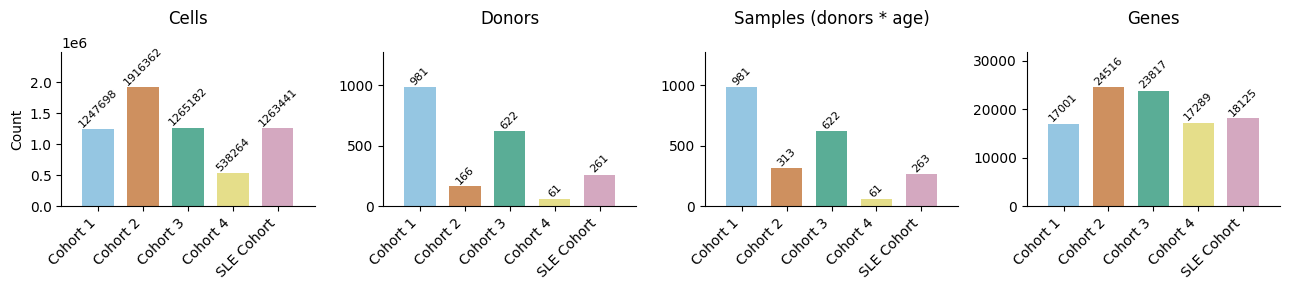

In [21]:
from ciim.src.common import palette_datasets

# Convert DataFrame to long format for easier plotting
df_long = df.melt(id_vars=["Dataset"], var_name="Metadata", value_name="Count")

fig, axes = plt.subplots(1, 4, figsize=(13, 3))
for i, metadata in enumerate(['Cells', 'Donors', 'Samples (donors * age)', 'Genes']):
    ax = axes[i]
    
    # Create bar plot
    sns.barplot(data=df, x='Dataset', y=metadata, alpha=.7, ax=ax, hue='Dataset', width=.7, palette=palette_datasets_pretty, legend=False)
    
    # Annotate bars with values (rotated 45 degrees)
    for p in ax.patches:
        ax.text(p.get_x() + p.get_width() / 2,  # X position
                p.get_height(),  # Y position (top of bar)
                f'{int(p.get_height())}',  # Text label
                ha='center', va='bottom', fontsize=8, rotation=45)  # Rotate 45 degrees

    # Formatting
    ax.set_title(metadata, pad=20)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.margins(x=0.1, y=0.3)
    
    if i == 0:
        ax.set_ylabel("Count")
    else:
        ax.set_ylabel("")
    
    ax.set_xlabel("")
    ax.legend().remove()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

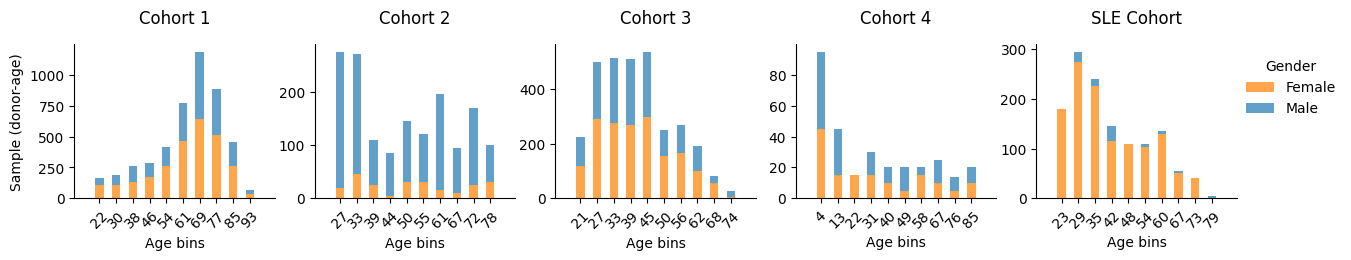

In [24]:
from ciim.src.common import palette_gender

fig, axes = plt.subplots(1, len(datasets_all), figsize=(3*len(datasets_all), 2), sharey=False)

for i, dataset in enumerate(datasets_all):
    adata = adata_lambda(dataset)
    
    df = adata.obs.copy()
    df['sex'] = df['sex'].apply(lambda name: {'F':'Female', 'M':'Male'}.get(name, name))

    # Count occurrences of each sex within each age group
    df_count = df.groupby(['age', 'sex']).size().reset_index(name='count')

    # Pivot data for stacking
    df_pivot = df_count.pivot(index='age', columns='sex', values='count').fillna(0)

    # Plot stacked bar chart
    df_pivot['binned'] = pd.cut(df_pivot.index, bins=10)  
    df_binned = df_pivot.groupby('binned').sum() 
    df_binned.plot(kind='bar', stacked=True, ax=axes[i], color=palette_gender, alpha=0.7)


    axes[i].set_xlabel("Age bins")
    axes[i].set_ylabel("Sample (donor-age)" if i == 0 else "")  
    axes[i].set_title(surrogate_names[dataset], pad=15)
    bin_midpoints = [int(interval.mid) for interval in df_binned.index.categories]
    axes[i].set_xticklabels(bin_midpoints)

    # Set x-axis ticks
    # axes[i].set_xticks(bin_midpoints)
    # Adjust xticks to show fewer labels
    # xtick_labels = [int(float(label.get_text())) for label in ]
    # step = max(1, len(xtick_labels) // 5)  # Show ~5 evenly spaced labels
    # axes[i].set_xticks(range(0, len(xtick_labels), step))
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)
    x_min, x_max = axes[i].get_xlim()
    axes[i].set_xlim(x_min - 1, x_max + 1) 
    
    axes[i].get_legend().remove()
axes[i].legend(loc=(1.02, .5), frameon=False, title='Gender')

plt.show()

## race

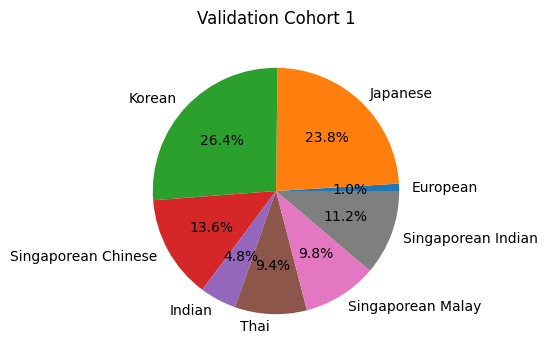

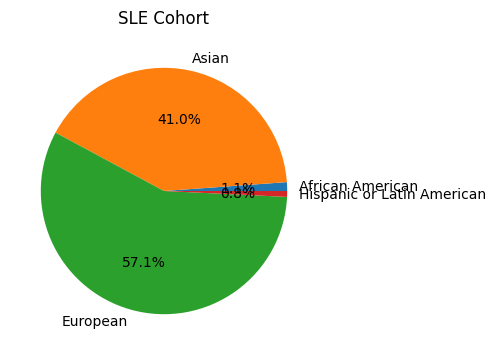

In [14]:
for dataset in ['data13', 'SLE']:
    if dataset == 'data13':
        adata = ad.read_h5ad(f'/vol/projects/CIIM/Healthy_Single_Cell_Data/count_matrix/{dataset}_CMtx.h5ad', backed='r')
    else:
        adata = adata_lambda(dataset)
    race_info = adata.obs.groupby('race')['donor_id'].nunique().reset_index(name='count')
    fig, ax = plt.subplots(1, 1, figsize=(4, 4))
    bb = ax.pie(race_info['count'], labels=race_info['race'], autopct='%1.1f%%')
    plt.title(surrogate_names[dataset], pad=10)

## Meta disease

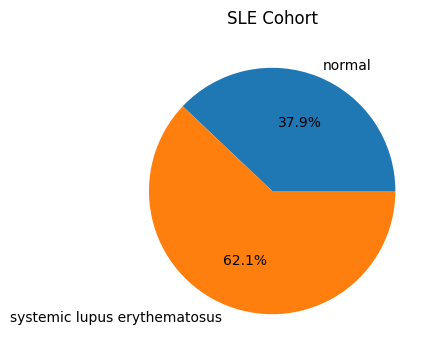

In [25]:
for dataset in ['SLE']:
    adata = adata_lambda(dataset)
    race_info = adata.obs.groupby('disease')['donor_id'].nunique().reset_index(name='count')
    fig, ax = plt.subplots(1, 1, figsize=(4, 4))
    bb = ax.pie(race_info['count'], labels=race_info['disease'], autopct='%1.1f%%')
    plt.title(surrogate_names[dataset], pad=10)

## Subcell types rations

In [58]:
obs_dict = {dataset: ad.read_h5ad(f'/vol/projects/jnourisa/datasets/{dataset}_sc.h5ad', backed='r').obs for dataset in datasets_all}

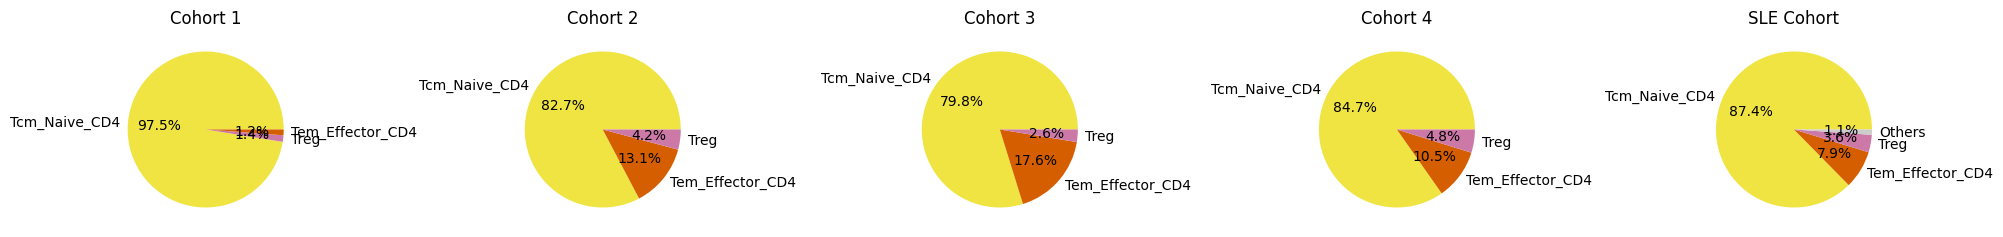

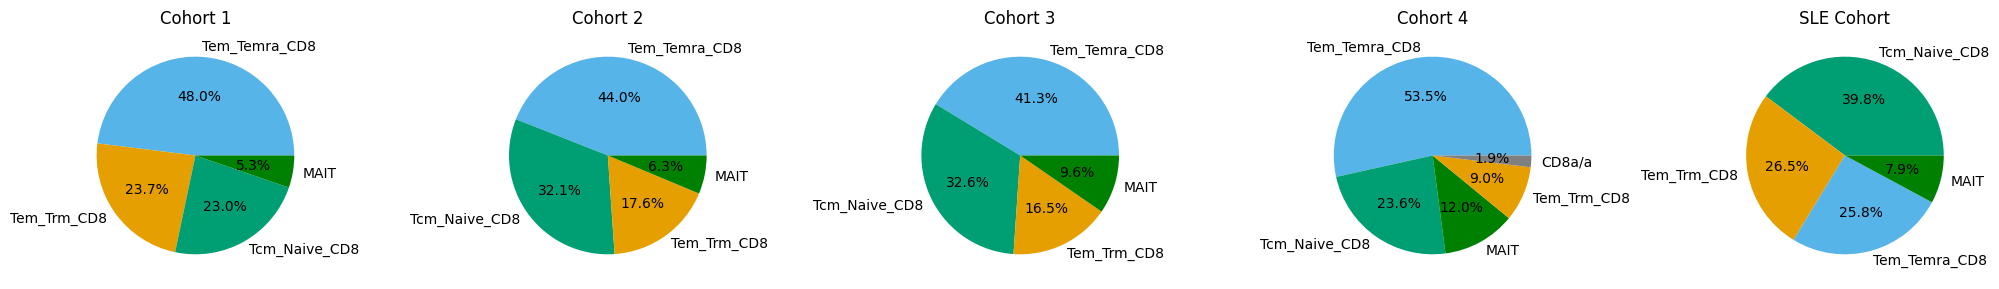

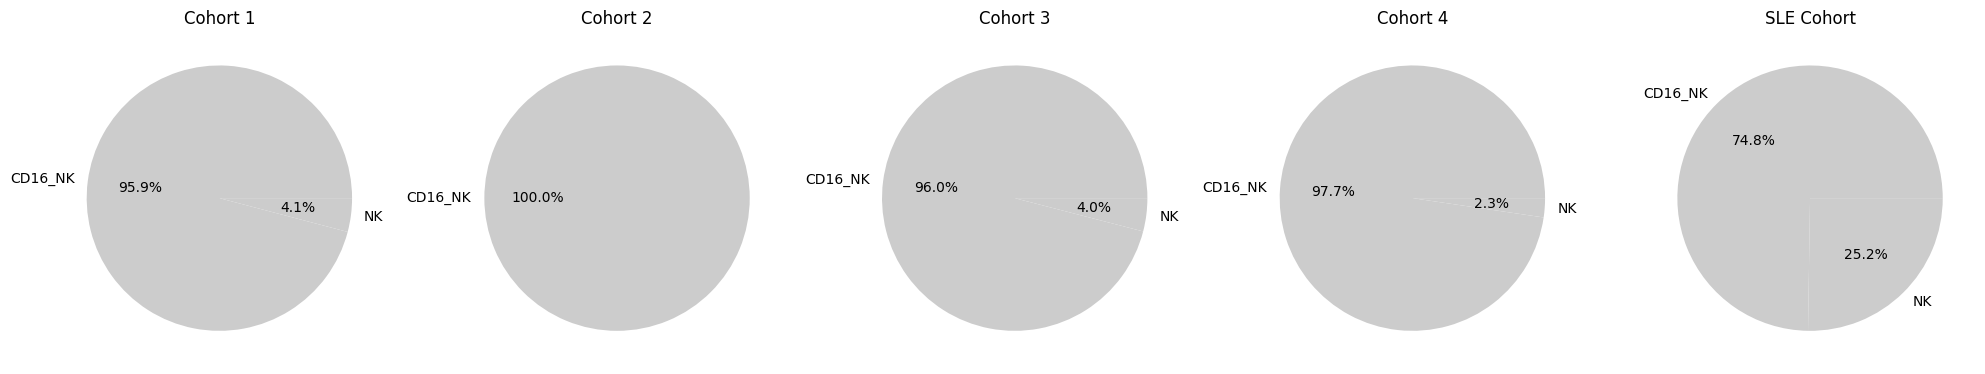

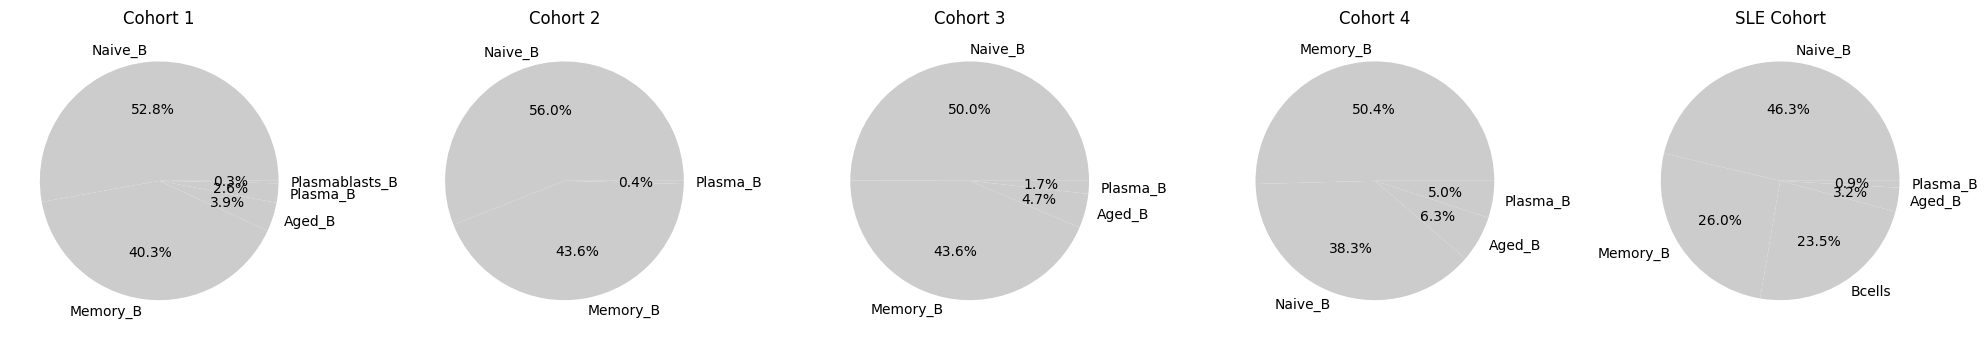

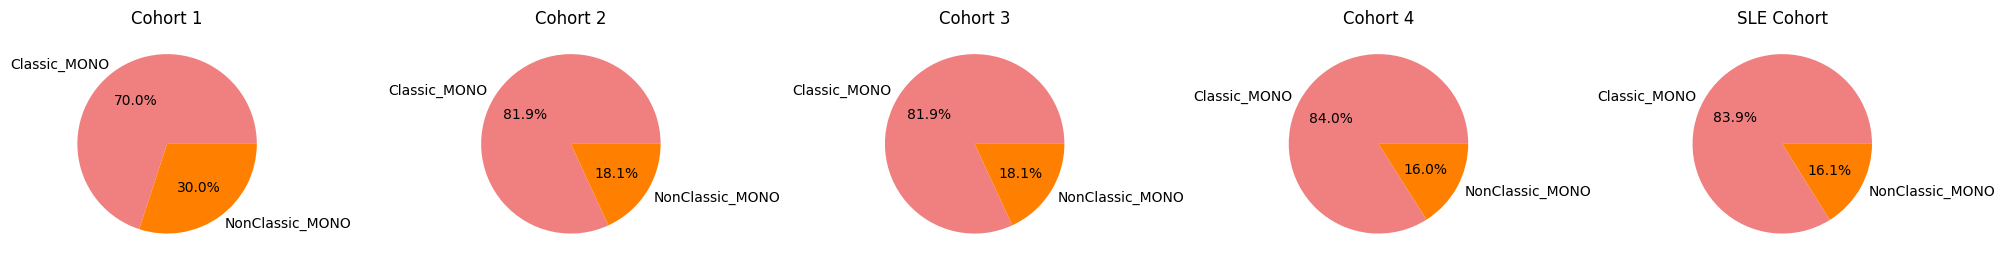

In [64]:
def pieplot(df, ax):
    """Create a pie chart with mapped colors."""
    df = df.to_frame(name='count')  # Convert Series to DataFrame
    df.index.name = 'cell_type'
    colors = [palette_sub_types[cell] if cell in palette_sub_types else "#cccccc" for cell in df.index]
    df.plot(kind='pie', y='count', autopct='%1.1f%%', colors=colors, ax=ax, legend=False)
    ax.set_ylabel('')
for j, cell_type in enumerate(cell_types):
    fig, axes = plt.subplots(1, len(datasets_all), figsize=(4*len(datasets_all), 4))
    for i, dataset in enumerate(datasets_all):
        obs = obs_dict[dataset]
        obs = obs[obs['Major_CT'] == cell_type]
        obs['Sub_CT'] = obs['Sub_CT'].astype(str)

        cell_type_counts = obs['Sub_CT'].value_counts()
        ax = axes[i]
        pieplot(cell_type_counts, ax)
        ax.set_title(surrogate_names[dataset])
    plt.tight_layout()

## Cell type frequency analysis

In [77]:
def calculate_freq(obs):
    # - calculate frequency 
    obs['Sub_CT'] = obs['Sub_CT'].astype(str)
    subct_counts = obs.groupby(['donor_id', 'Sub_CT']).size().reset_index(name='count')
    total_counts = obs.groupby('donor_id').size().reset_index(name='total')
    freq = subct_counts.merge(total_counts, on='donor_id')
    freq['ratio'] = freq['count'] / freq['total']
    metadata_cols = ['donor_id', 'age', 'age_group']
    metadata = obs[metadata_cols].drop_duplicates()
    freq = freq.merge(metadata, on='donor_id', how='left')
    return freq

freq_store = []
for j, cell_type in enumerate(cell_types):
    for i, dataset in enumerate(datasets_all):
        obs = obs_dict[dataset]
        obs = obs[obs['cell_type'] == cell_type]
        freq = calculate_freq(obs)
        freq['dataset'] = dataset
        freq_store.append(freq)
freq_df = pd.concat(freq_store)

In [111]:
# freq_df['dataset'].unique(), freq_df['Sub_CT'].unique(), freq_df['age_group'].unique()

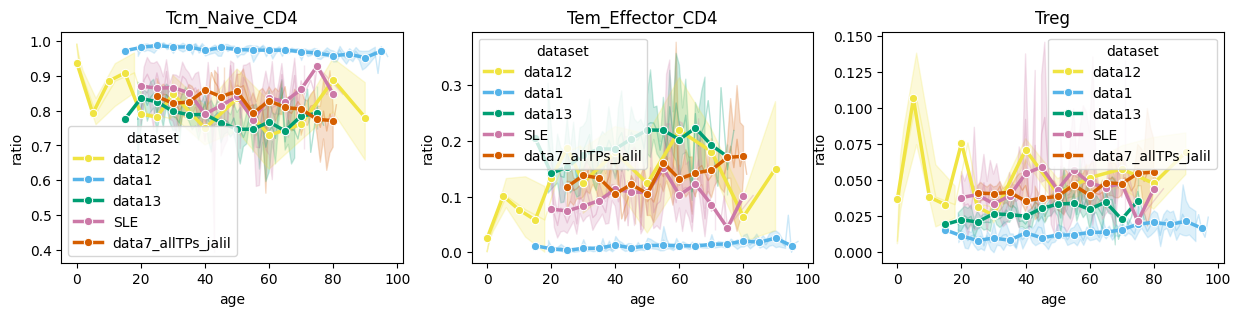

In [92]:
from ciim.src.common import mapping_major_2_minor
for j, cell_type in enumerate(['CD4T']):
    subtypes = mapping_major_2_minor[cell_type]
    fig, axes = plt.subplots(1, len(subtypes), figsize=(5*len(subtypes), 3))
    for i, subtype in enumerate(subtypes):
        ax = axes[i]
        freq = freq_df[freq_df['Sub_CT'] == subtype]
        freq['age_bin'] = (freq['age'] // 5 * 5).astype(int)  # e.g., 48 → 45, 53 → 50

        mean_ratio = (
            freq.groupby(['age_bin', 'dataset'], as_index=False)
            .agg({'ratio': 'mean'})
        )
        sns.lineplot(data=freq, x='age', y='ratio', hue='dataset', alpha=0.3, linewidth=1, legend=False, palette=palette_datasets, ax=ax)
        sns.lineplot(data=mean_ratio, x='age_bin', y='ratio', hue='dataset', linewidth=2.5, marker='o', palette=palette_datasets, ax=ax)

        ax.set_title(subtype)

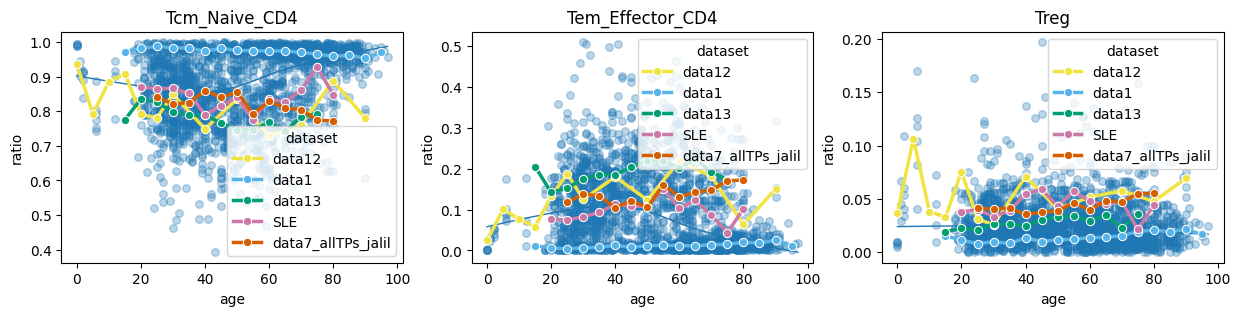

In [117]:
from ciim.src.common import mapping_major_2_minor
import seaborn as sns
import matplotlib.pyplot as plt

for j, cell_type in enumerate(['CD4T']):
    subtypes = mapping_major_2_minor[cell_type]
    fig, axes = plt.subplots(1, len(subtypes), figsize=(5 * len(subtypes), 3))
    for i, subtype in enumerate(subtypes):
        ax = axes[i]
        freq = freq_df[freq_df['Sub_CT'] == subtype]
        freq['age_bin'] = (freq['age'] // 5 * 5).astype(int)  # e.g., 48 → 45, 53 → 50

        mean_ratio = (
            freq.groupby(['age_bin', 'dataset'], as_index=False)
            .agg({'ratio': 'mean'})
        )
        
        # Scatter plot with loess smoothing
        sns.regplot(data=freq, x='age', y='ratio', scatter_kws={'alpha':0.3, 's':30}, 
                    line_kws={'linewidth': 1}, lowess=True, ci=None,  ax=ax)

        # Plot the smoothed mean ratio
        sns.lineplot(data=mean_ratio, x='age_bin', y='ratio', hue='dataset', linewidth=2.5, marker='o', palette=palette_datasets, ax=ax)

        ax.set_title(subtype)

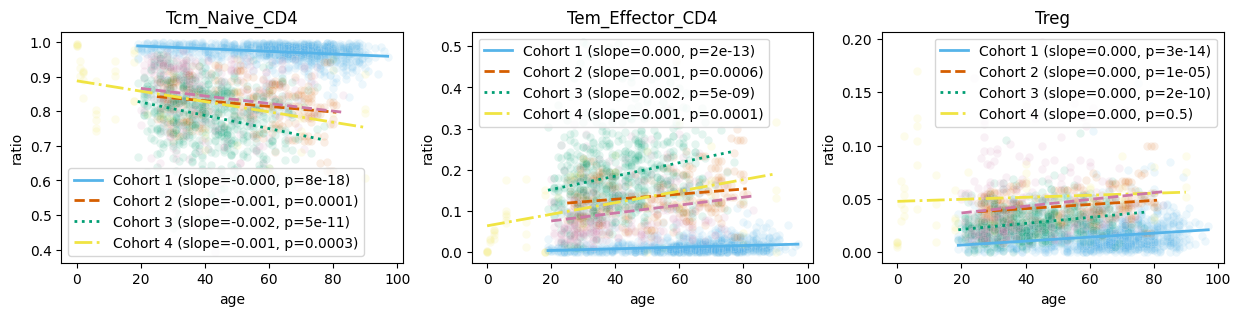

In [114]:
import statsmodels.api as sm
from scipy import stats

from ciim.src.common import mapping_major_2_minor

line_styles = ['-', '--', ':', '-.', '--', '-', '..', '-..']
for cell_type in ['CD4T']:
    subtypes = mapping_major_2_minor[cell_type]
    fig, axes = plt.subplots(1, len(subtypes), figsize=(5*len(subtypes), 3))
    for i, subtype in enumerate(subtypes):
        ax = axes[i]
        for j, dataset in enumerate(freq_df['dataset'].unique()):
            df_sub = freq_df[(freq_df['dataset'] == dataset)&(freq_df['Sub_CT'] == subtype)]
            sns.scatterplot(data=df_sub, x='age', y='ratio', color=palette_datasets[dataset], alpha=0.1, label=None, ax=ax)
            # Linear model
            X = sm.add_constant(df_sub['age'])
            model = sm.OLS(df_sub['ratio'], X).fit()
            slope = model.params['age']
            pval = model.pvalues['age']
            
            # Predict line
            x_vals = df_sub['age'].sort_values()
            y_vals = model.predict(sm.add_constant(x_vals))
            
            ax.plot(x_vals, y_vals, linestyle=line_styles[j], color=palette_datasets[dataset], label=f"{surrogate_names[dataset]} (slope={slope:.3f}, p={pval:.1g})", linewidth=2)

        ax.set_title(subtype)

# Explanatory plots

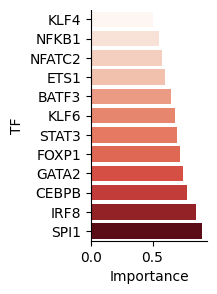

In [27]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Example data with more TFs
df = pd.DataFrame({
    'TF': ['SPI1', 'IRF8', 'CEBPB', 'GATA2', 'FOXP1', 'STAT3', 
           'KLF6', 'BATF3', 'ETS1', 'NFATC2', 'NFKB1', 'KLF4'],
    'Importance': [0.9, 0.85, 0.78, 0.75, 0.72, 0.70, 0.68, 0.65, 0.6, 0.58, 0.55, 0.5]
})

# Sort values for better visualization
df = df.sort_values(by='Importance', ascending=True)

# Create color gradient based on importance
norm = plt.Normalize(df['Importance'].min(), df['Importance'].max())
colors = sns.color_palette("Reds", as_cmap=True)(norm(df['Importance']))

# Plot
plt.figure(figsize=(1.5, 3))
ax = sns.barplot(data=df, y='TF', x='Importance', palette=colors)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xlabel('Importance')
plt.ylabel('TF')
# plt.title('Robust predictors of age')

plt.show()